In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive')
print(os.listdir())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Pitch.gslides', 'Sink Holes.gslides', 'Untitled document (3).gdoc', 'Resume.gdoc', 'Letter.gdoc', 'Hurricane Sandy.gslides', 'Untitled document (2).gdoc', 'Fire Inspection.gslides', 'Wind and Solar Power.gslides', 'Fairmount Fire.gdoc', 'Chapter 2 Building And Construction Plans and Codes.gslides', 'Building and construction final.gslides', '2_0241 Lateral Move Instructions.gdoc', 'Untitled document (1).gdoc', 'Student Handouts', 'NAVMC 11799 SPONSORSHIP REQUEST.PDF.gdoc', 'Untitled spreadsheet (1).gsheet', '36380358-eTranscript.pdf', "MARINE CORPS MARTIAL ARTS PROGRAM INSTRUCTOR'S (1).pdf", "MARINE CORPS MARTIAL ARTS PROGRAM INSTRUCTOR'S.pdf", 'image_67213313.JPG', '\n (2).txt', 'Weight Of Vehicle Without Material.pdf', '\n (1).txt', 'Weight Ticket With The Material.pdf', '\n.txt', 'DD 1351-2.pdf', '\n\n.txt', 'DD 2278.pdf', 'VBA-28-1905m-ARE_May 2024.pdf'

In [8]:
# =============================================================================
# OLS PIPELINE — 3 RESERVOIRS (Navajo, Blue Mesa, Pueblo)
# =============================================================================
# Model:  jun_jul_af  ~  antecedent_oct1_af  +  may_june_mean_cfs
#   X : antecedent Oct-1 storage  +  May-June streamflow
#   Y : June-July mean reservoir storage (acre-feet)
#   Train : water years 1980-2014   (chronological holdout)
#   Test  : water years 2015-2025
#
# Fixes vs the crashing version:
#   * fit_ols() now GUARDS an empty train/test split instead of throwing
#     `Found array with 0 sample(s)` — a reservoir with no rows in the test
#     window is handled, not fatal.
#   * A coverage diagnostic prints usable rows + year range per reservoir
#     BEFORE fitting, so a gap (e.g. Pueblo missing 2015-2025 storage) is
#     visible immediately.
#   * ALLOW_PROPORTIONAL_FALLBACK: if a reservoir has usable rows but none in
#     the 2015+ test window, it falls back to a per-reservoir chronological
#     split (last TEST_FRACTION of its own years) so it still yields a model,
#     with a loud NOTE. Set False to skip such reservoirs instead.
#   * The dead run_stage2 / build_team_predictors / load_merged_table cells
#     (undefined leftovers from the SWE/temp version) were removed. The
#     predictor-comparison section below auto-detects which columns exist, so
#     it works with or without SWE/temperature in the features file.
# =============================================================================

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# ---- FILES (both expected in /content/drive/MyDrive/) -----------------------
FEATURES_FILE   = "3reservoir_features_all.csv"
STREAMFLOW_FILE = "three_reservoirs_may_june_streamflow_1980_2025.csv"

# ---- COLUMNS ----------------------------------------------------------------
TARGET_COL     = "jun_jul_af"          # Y: June-July mean storage
ANTECEDENT_COL = "antecedent_oct1_af"  # X1: prior-year (Oct-1) antecedent storage
STREAMFLOW_COL = "may_june_mean_cfs"   # X2: May-June streamflow  <-- EDIT IF NEEDED

PREDICTORS = [ANTECEDENT_COL, STREAMFLOW_COL]

# ---- TRAIN / TEST SPLIT (no year appears in both) ---------------------------
TRAIN_END  = 2014   # train: 1980..2014
TEST_START = 2015   # test:  2015..2025

# ---- ROBUSTNESS KNOBS -------------------------------------------------------
MIN_TRAIN = 2       # need at least this many train rows to fit
MIN_TEST  = 1       # need at least this many test rows to evaluate
ALLOW_PROPORTIONAL_FALLBACK = True   # see header note; set False to skip instead
TEST_FRACTION = 0.24                 # fallback holdout size (~ matches 11/46)

RESERVOIR_ORDER = ["Navajo Reservoir", "Blue Mesa Reservoir", "Pueblo Reservoir"]

In [9]:
# -----------------------------------------------------------------------------
# LOAD + MERGE  (reservoir features  <->  streamflow, keyed on reservoir + year)
# -----------------------------------------------------------------------------

def _canon(name: str) -> str:
    """Canonicalize a reservoir label so 'Blue Mesa Reservoir', 'blue_mesa',
    and 'Blue Mesa' all match on merge."""
    return (str(name).lower()
            .replace("reservoir", "").replace("lake", "")
            .replace("_", " ").strip())


def load_data():
    feat = pd.read_csv(FEATURES_FILE)
    flow = pd.read_csv(STREAMFLOW_FILE)

    flow.columns = [c.strip() for c in flow.columns]

    global STREAMFLOW_COL
    if STREAMFLOW_COL not in flow.columns:
        guesses = [c for c in flow.columns
                   if ("cfs" in c.lower() or "flow" in c.lower())
                   and c.lower() not in ("water_year", "year")]
        if len(guesses) == 1:
            print(f"NOTE: '{STREAMFLOW_COL}' not found; auto-detected "
                  f"streamflow column '{guesses[0]}' instead.")
            STREAMFLOW_COL = guesses[0]
            PREDICTORS[1] = STREAMFLOW_COL
        else:
            raise KeyError(
                f"Could not find streamflow column '{STREAMFLOW_COL}' in "
                f"{STREAMFLOW_FILE}. Columns present: {list(flow.columns)}. "
                f"Set STREAMFLOW_COL in the config cell.")

    for d in (feat, flow):
        if "water_year" not in d.columns and "year" in d.columns:
            d.rename(columns={"year": "water_year"}, inplace=True)

    feat["_key"] = feat["reservoir"].map(_canon)
    if "reservoir" in flow.columns:
        flow["_key"] = flow["reservoir"].map(_canon)
        merged = feat.merge(
            flow[["_key", "water_year", STREAMFLOW_COL]],
            on=["_key", "water_year"], how="left")
    else:
        print("NOTE: streamflow file has no 'reservoir' column; joining the "
              "same flow series to all reservoirs on water_year only.")
        merged = feat.merge(
            flow[["water_year", STREAMFLOW_COL]],
            on="water_year", how="left")

    merged.drop(columns="_key", inplace=True)

    missing = merged[merged[STREAMFLOW_COL].isna()]
    if len(missing):
        print(f"WARNING: {len(missing)} rows got no streamflow match "
              f"(reservoir-name or year mismatch between the two files).")
        print(missing[["reservoir", "water_year"]].to_string(index=False))
    else:
        print("Streamflow merged cleanly onto all reservoir-years.")

    print(f"Merged table: {merged.shape[0]} rows "
          f"({merged['reservoir'].nunique()} reservoirs, "
          f"{merged['water_year'].min()}-{merged['water_year'].max()})")
    return merged


df = load_data()
display(df.head())

       reservoir  water_year
Pueblo Reservoir        2008
Pueblo Reservoir        2009
Pueblo Reservoir        2010
Pueblo Reservoir        2011
Pueblo Reservoir        2012
Pueblo Reservoir        2013
Pueblo Reservoir        2014
Pueblo Reservoir        2015
Pueblo Reservoir        2016
Pueblo Reservoir        2017
Pueblo Reservoir        2018
Pueblo Reservoir        2019
Pueblo Reservoir        2020
Pueblo Reservoir        2021
Pueblo Reservoir        2022
Pueblo Reservoir        2023
Pueblo Reservoir        2024
Pueblo Reservoir        2025
Merged table: 138 rows (3 reservoirs, 1980-2025)


,reservoir,water_year,jun_mean_af,jul_mean_af,jun_jul_af,antecedent_oct1_af,n_days_jun,n_days_jul,may_june_mean_cfs
0,Blue Mesa Reservoir,1980,654840.600000,812654.032258,735040.868852,707949.571429,30,31,2747.540984
1,Blue Mesa Reservoir,1981,419770.466667,423003.387097,421413.426230,736363.000000,30,31,681.213115
2,Blue Mesa Reservoir,1982,528832.333333,700586.548387,616117.262295,376441.571429,30,31,1922.983607
3,Blue Mesa Reservoir,1983,725246.133333,818909.193548,772845.393443,737546.000000,30,31,2082.327869
4,Blue Mesa Reservoir,1984,765353.333333,813931.096774,790040.393443,738523.571429,30,31,3784.409836


In [10]:
# -----------------------------------------------------------------------------
# COVERAGE DIAGNOSTIC + GUARDED OLS FIT/EVAL  (per reservoir)
# -----------------------------------------------------------------------------

def coverage(data, predictors, target=TARGET_COL):
    """Print usable rows + year range + train/test counts per reservoir, so a
    data gap (short record, missing recent storage, failed flow merge) is
    obvious before any model runs."""
    print("COVERAGE  (usable = complete rows across predictors + target)")
    for name in RESERVOIR_ORDER:
        sub = data[data.reservoir == name]
        u = sub.dropna(subset=predictors + [target])
        if len(u):
            in_tr = int((u.water_year <= TRAIN_END).sum())
            in_te = int((u.water_year >= TEST_START).sum())
            flag = "   <-- no test-window rows" if in_te == 0 else ""
            print(f"  {name:22s} rows={len(sub):3d} usable={len(u):3d} "
                  f"years={int(u.water_year.min())}-{int(u.water_year.max())} "
                  f"train={in_tr:2d} test={in_te:2d}{flag}")
        else:
            print(f"  {name:22s} rows={len(sub):3d} usable=  0  "
                  f"(no complete rows across {predictors} + {target})")
    print()


def split_train_test(d):
    """Chronological holdout: train <= TRAIN_END, test >= TEST_START.
    If a reservoir has usable rows but NONE in the test window, optionally fall
    back to a per-reservoir chronological split so it still yields a model."""
    train = d[d.water_year <= TRAIN_END].copy()
    test  = d[d.water_year >= TEST_START].copy()

    if len(test) == 0 and ALLOW_PROPORTIONAL_FALLBACK and len(d) >= 5:
        ds = d.sort_values("water_year")
        n_test = max(MIN_TEST, int(round(TEST_FRACTION * len(ds))))
        train = ds.iloc[:-n_test].copy()
        test  = ds.iloc[-n_test:].copy()
        print(f"    [fallback] no rows in {TEST_START}+ test window; using the "
              f"last {n_test} of {len(ds)} usable years "
              f"({int(test.water_year.min())}-{int(test.water_year.max())}) "
              f"as test for this reservoir.")
    return train, test


def report_vif(X):
    Xc = sm.add_constant(X)
    print("  VIF (>5 flag, >10 serious):")
    for i, col in enumerate(Xc.columns):
        if col == "const":
            continue
        print(f"    {col:<22} VIF = {variance_inflation_factor(Xc.values, i):6.2f}")


def fit_ols(d, predictors, target=TARGET_COL, label="", verbose=True):
    """Fit OLS on the train split, evaluate on the test split. Returns a result
    dict, or None (with a clear message) when there aren't enough usable rows
    to fit/evaluate — so one thin reservoir no longer crashes the whole run."""
    d = d.dropna(subset=predictors + [target])
    train, test = split_train_test(d)

    if len(train) < MIN_TRAIN or len(test) < MIN_TEST:
        print(f"\n{'='*70}\n{label}")
        print(f"  [skip] train={len(train)} test={len(test)} — too few usable "
              f"rows to fit/evaluate (need train>={MIN_TRAIN}, test>={MIN_TEST}).")
        print(f"         Check this reservoir's storage record and the "
              f"streamflow merge (see the COVERAGE table above).")
        return None

    Xtr, ytr = train[predictors].values, train[target].values
    Xte, yte = test[predictors].values,  test[target].values

    ols = LinearRegression().fit(Xtr, ytr)
    tr_pred, te_pred = ols.predict(Xtr), ols.predict(Xte)

    res = {
        "label": label,
        "predictors": ", ".join(predictors),
        "n_train": len(train), "n_test": len(test),
        "train_r2": r2_score(ytr, tr_pred),
        "test_r2":  r2_score(yte, te_pred) if len(yte) > 1 else np.nan,
        "train_rmse_af": np.sqrt(mean_squared_error(ytr, tr_pred)),
        "test_rmse_af":  np.sqrt(mean_squared_error(yte, te_pred)),
    }

    if verbose:
        print(f"\n{'='*70}")
        print(f"{label}")
        print(f"  predictors: {predictors}")
        print(f"  target:     {target}")
        print(f"  n_train={len(train)}  n_test={len(test)}")
        print(f"  TRAIN  R2={res['train_r2']:6.3f}  RMSE={res['train_rmse_af']:12,.0f} af")
        te_r2 = res['test_r2']
        te_r2_s = f"{te_r2:6.3f}" if not np.isnan(te_r2) else "   nan"
        print(f"  TEST   R2={te_r2_s}  RMSE={res['test_rmse_af']:12,.0f} af")
        print("  coefficients:")
        for c, b in zip(predictors, ols.coef_):
            print(f"    {c:<22} {b:16,.4f}")
        print(f"    {'intercept':<22} {ols.intercept_:16,.2f}")
        report_vif(train[predictors])

    test = test.copy()
    test["predicted_" + target] = te_pred
    res["model"] = ols
    res["test_frame"] = test
    return res

In [11]:
# -----------------------------------------------------------------------------
# RUN — full 2-predictor model, per reservoir + pooled
# -----------------------------------------------------------------------------

coverage(df, PREDICTORS)

per_reservoir = {}
pred_frames = []

for name in RESERVOIR_ORDER:
    sub = df[df.reservoir == name]
    if sub.empty:
        print(f"(skipping {name} — not in data)")
        continue
    r = fit_ols(sub, PREDICTORS, label=f"MODEL — {name}")
    if r is None:
        continue
    per_reservoir[name] = r
    pred_frames.append(r["test_frame"].assign(reservoir=name))

# Pooled model across all 3 reservoirs.
# CAVEAT: storage magnitudes differ ~5x (Navajo ~1.7M AF vs Pueblo ~0.35M AF),
# so a single raw-acre-foot OLS is dominated by the largest reservoir. Kept as
# a coarse statewide read; the per-reservoir models above are the primary result.
print("\n" + "#"*70)
print("# POOLED across all 3 reservoirs (see caveat in code comment)")
print("#"*70)
pooled = fit_ols(df, PREDICTORS, label="MODEL — POOLED (3 reservoirs)")

rows_for_summary = list(per_reservoir.values()) + ([pooled] if pooled else [])
summary = pd.DataFrame(
    [{k: v for k, v in r.items()
      if k in ("label", "n_train", "n_test", "train_r2", "test_r2",
               "train_rmse_af", "test_rmse_af")}
     for r in rows_for_summary]
)
print("\nSUMMARY")
display(summary.round(3))

COVERAGE  (usable = complete rows across predictors + target)
  Navajo Reservoir       rows= 46 usable= 46 years=1980-2025 train=35 test=11
  Blue Mesa Reservoir    rows= 46 usable= 46 years=1980-2025 train=35 test=11
  Pueblo Reservoir       rows= 46 usable= 28 years=1980-2007 train=28 test= 0   <-- no test-window rows


MODEL — Navajo Reservoir
  predictors: ['antecedent_oct1_af', 'may_june_mean_cfs']
  target:     jun_jul_af
  n_train=35  n_test=11
  TRAIN  R2= 0.653  RMSE=     118,096 af
  TEST   R2= 0.659  RMSE=     102,330 af
  coefficients:
    antecedent_oct1_af               0.4457
    may_june_mean_cfs              135.2945
    intercept                    593,840.27
  VIF (>5 flag, >10 serious):
    antecedent_oct1_af     VIF =   1.09
    may_june_mean_cfs      VIF =   1.09

MODEL — Blue Mesa Reservoir
  predictors: ['antecedent_oct1_af', 'may_june_mean_cfs']
  target:     jun_jul_af
  n_train=35  n_test=11
  TRAIN  R2= 0.474  RMSE=      81,876 af
  TEST   R2= 0.453  RMSE=  

,label,n_train,n_test,train_r2,test_r2,train_rmse_af,test_rmse_af
0,MODEL — Navajo Reservoir,35,11,0.653,0.659,118095.608,102329.873
1,MODEL — Blue Mesa Reservoir,35,11,0.474,0.453,81876.408,105616.939
2,MODEL — Pueblo Reservoir,21,7,0.724,0.497,35139.841,26205.350
3,MODEL — POOLED (3 reservoirs),98,22,0.937,0.724,131041.135,191741.106


In [12]:
# -----------------------------------------------------------------------------
# PREDICTOR COMPARISON (pooled) — auto-detects which predictor columns exist,
# so this runs whether or not the features file carries SWE / temperature.
# -----------------------------------------------------------------------------

CANDIDATE_PREDICTORS = {
    "swe_nov_apr_mean_in": "SWE",
    "temp_aprjun_c":       "Temp",
    STREAMFLOW_COL:        "Streamflow",
    ANTECEDENT_COL:        "Antecedent storage",
}
available = [c for c in CANDIDATE_PREDICTORS if c in df.columns]
print("Predictor columns available in df:", available)

model_sets = {CANDIDATE_PREDICTORS[c] + " only": [c] for c in available}
if STREAMFLOW_COL in df.columns and ANTECEDENT_COL in df.columns:
    model_sets["Streamflow + Antecedent"] = [STREAMFLOW_COL, ANTECEDENT_COL]
_full = ["swe_nov_apr_mean_in", "temp_aprjun_c", STREAMFLOW_COL, ANTECEDENT_COL]
if all(c in df.columns for c in _full):
    model_sets["Full (SWE+Temp+Flow+Antecedent)"] = _full

comparison_rows = []
for label, preds in model_sets.items():
    clean = df.dropna(subset=preds + [TARGET_COL])
    train, test = split_train_test(clean)
    if len(train) < MIN_TRAIN or len(test) < MIN_TEST:
        print(f"  [skip] {label}: train={len(train)} test={len(test)}")
        continue
    m = LinearRegression().fit(train[preds].values, train[TARGET_COL].values)
    tr_pred = m.predict(train[preds].values)
    te_pred = m.predict(test[preds].values)
    comparison_rows.append({
        "model": label,
        "predictors": ", ".join(preds),
        "train_r2": r2_score(train[TARGET_COL], tr_pred),
        "test_r2":  r2_score(test[TARGET_COL], te_pred) if len(test) > 1 else np.nan,
        "train_rmse_af": np.sqrt(mean_squared_error(train[TARGET_COL], tr_pred)),
        "test_rmse_af":  np.sqrt(mean_squared_error(test[TARGET_COL], te_pred)),
    })

model_comparison = pd.DataFrame(comparison_rows).sort_values("test_rmse_af")
display(model_comparison.round(3))

Predictor columns available in df: ['may_june_mean_cfs', 'antecedent_oct1_af']


,model,predictors,train_r2,test_r2,train_rmse_af,test_rmse_af
1,Antecedent storage only,antecedent_oct1_af,0.937,0.848,132177.065,173935.798
2,Streamflow + Antecedent,"may_june_mean_cfs, antecedent_oct1_af",0.937,0.724,131041.135,191741.106
0,Streamflow only,may_june_mean_cfs,0.001,-0.151,521181.252,391548.566


In [13]:
# -----------------------------------------------------------------------------
# BEST MODEL applied to one reservoir: observed vs predicted on the test years.
# -----------------------------------------------------------------------------
PLOT_RESERVOIR = "Blue Mesa Reservoir"   # change to inspect a different one

best_row = model_comparison.iloc[0]
best_predictors = best_row["predictors"].split(", ")
print(f"Best model by test RMSE: {best_row['model']}  ->  {best_predictors}")

sub = df[df.reservoir == PLOT_RESERVOIR].dropna(subset=best_predictors + [TARGET_COL])
train, test = split_train_test(sub)

best_model = LinearRegression().fit(train[best_predictors].values,
                                    train[TARGET_COL].values)
test = test.copy()
test["predicted_" + TARGET_COL] = best_model.predict(test[best_predictors].values)
display(test[["water_year", TARGET_COL, "predicted_" + TARGET_COL]])

Best model by test RMSE: Antecedent storage only  ->  ['antecedent_oct1_af']


,water_year,jun_jul_af,predicted_jun_jul_af
35,2015,796735.196721,667826.889696
36,2016,746675.377049,710603.055454
37,2017,749308.081967,689777.151143
38,2018,464807.852459,712903.393867
39,2019,667515.409836,558387.239317
40,2020,582344.163934,714076.286520
41,2021,375340.459016,611520.933591
42,2022,376726.967213,544443.034090
43,2023,727012.426230,562129.082608
44,2024,596831.049180,677764.855625


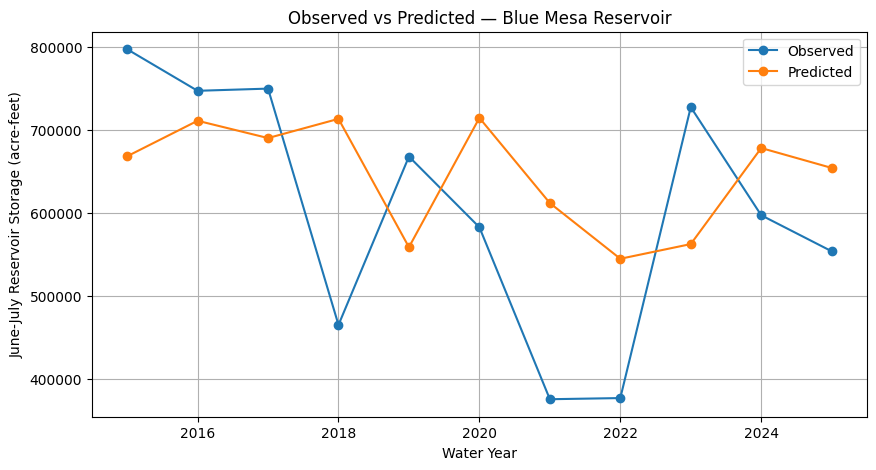

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(test["water_year"], test[TARGET_COL], marker="o", label="Observed")
plt.plot(test["water_year"], test["predicted_" + TARGET_COL], marker="o", label="Predicted")
plt.xlabel("Water Year")
plt.ylabel("June-July Reservoir Storage (acre-feet)")
plt.title(f"Observed vs Predicted — {PLOT_RESERVOIR}")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
out_name = PLOT_RESERVOIR.lower().replace(" ", "_") + "_test_predictions.csv"
test[["water_year", TARGET_COL, "predicted_" + TARGET_COL]].to_csv(out_name, index=False)
print("Wrote", out_name)

Wrote blue_mesa_reservoir_test_predictions.csv


In [20]:
# -----------------------------------------------------------------------------
# FINAL — test-set RMSE by predictor set, and OLS vs Ridge vs Lasso.
#   * Answers "which X variables give the lowest RMSE" and "was Lasso/Ridge
#     tested" in one table.
#   * Ridge/Lasso are fit on STANDARDIZED predictors (their penalties are
#     scale-sensitive, and antecedent_af ~1e6 vs streamflow ~1e3 vs SWE ~20),
#     with alpha chosen by cross-validation. RMSE is reported back in acre-feet
#     so every column is directly comparable to the OLS column.
#   * Runs on the pooled frame by default (same caveat as the pooled model:
#     Navajo's ~1.7M AF dominates). Call compare_models(df[df.reservoir==NAME])
#     to get the table for a single reservoir instead.
# -----------------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV, LassoCV

RIDGE_ALPHAS = np.logspace(-2, 8, 40)

def _rmse(y, p):
    return float(np.sqrt(mean_squared_error(y, p)))

def compare_models(frame, label="POOLED (3 reservoirs)"):
    rows = []
    for set_name, preds in model_sets.items():
        clean = frame.dropna(subset=preds + [TARGET_COL])
        train, test = split_train_test(clean)
        if len(train) < MIN_TRAIN or len(test) < MIN_TEST:
            print(f"  [skip] {set_name}: train={len(train)} test={len(test)}")
            continue
        Xtr, ytr = train[preds].values, train[TARGET_COL].values
        Xte, yte = test[preds].values,  test[TARGET_COL].values

        estimators = {
            "OLS":   LinearRegression(),
            "Ridge": make_pipeline(StandardScaler(), RidgeCV(alphas=RIDGE_ALPHAS)),
            "Lasso": make_pipeline(StandardScaler(),
                                   LassoCV(cv=min(5, len(train)), max_iter=200000)),
        }
        row = {"predictors": ", ".join(preds),
               "n_train": len(train), "n_test": len(test)}
        for mname, est in estimators.items():
            est.fit(Xtr, ytr)
            row[f"{mname}_test_rmse_af"] = _rmse(yte, est.predict(Xte))
        rows.append(row)

    out = (pd.DataFrame(rows)
             .sort_values("OLS_test_rmse_af")
             .reset_index(drop=True))
    print(f"\nTest-set RMSE (acre-feet) by predictor set  —  {label}")
    display(out.round(0))
    return out

rmse_by_model = compare_models(df)


# Per-reservoir RMSE tables (OLS vs Ridge vs Lasso)
for _name in RESERVOIR_ORDER:
    compare_models(df[df.reservoir == _name], label=_name)


Test-set RMSE (acre-feet) by predictor set  —  POOLED (3 reservoirs)


,predictors,n_train,n_test,OLS_test_rmse_af,Ridge_test_rmse_af,Lasso_test_rmse_af
0,antecedent_oct1_af,105,33,173936.0,173937.0,173936.0
1,"may_june_mean_cfs, antecedent_oct1_af",98,22,191741.0,191793.0,191964.0
2,may_june_mean_cfs,98,22,391549.0,389141.0,389141.0



Test-set RMSE (acre-feet) by predictor set  —  Navajo Reservoir


,predictors,n_train,n_test,OLS_test_rmse_af,Ridge_test_rmse_af,Lasso_test_rmse_af
0,"may_june_mean_cfs, antecedent_oct1_af",35,11,102330.0,105897.0,102410.0
1,may_june_mean_cfs,35,11,159230.0,161757.0,159274.0
2,antecedent_oct1_af,35,11,178223.0,178056.0,178215.0



Test-set RMSE (acre-feet) by predictor set  —  Blue Mesa Reservoir


,predictors,n_train,n_test,OLS_test_rmse_af,Ridge_test_rmse_af,Lasso_test_rmse_af
0,"may_june_mean_cfs, antecedent_oct1_af",35,11,105617.0,109406.0,106960.0
1,may_june_mean_cfs,35,11,122017.0,122830.0,122175.0
2,antecedent_oct1_af,35,11,147708.0,147505.0,147704.0


    [fallback] no rows in 2015+ test window; using the last 7 of 28 usable years (2001-2007) as test for this reservoir.
    [fallback] no rows in 2015+ test window; using the last 7 of 28 usable years (2001-2007) as test for this reservoir.

Test-set RMSE (acre-feet) by predictor set  —  Pueblo Reservoir


,predictors,n_train,n_test,OLS_test_rmse_af,Ridge_test_rmse_af,Lasso_test_rmse_af
0,antecedent_oct1_af,35,11,22326.0,22458.0,22339.0
1,"may_june_mean_cfs, antecedent_oct1_af",21,7,26205.0,28798.0,26254.0
2,may_june_mean_cfs,21,7,41717.0,49156.0,41746.0
